# Task 2: Bayesian Change Point Detection for Brent Crude Oil Prices

## Objective

The objective of this task is to identify statistically significant structural changes in Brent crude oil prices using Bayesian Change Point Detection implemented in PyMC. The detected change points will later be compared with major geopolitical and economic events to understand whether important historical events coincide with significant market changes.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import sys

!{sys.executable} -m pip install pymc arviz
import arviz as az

from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv("../data/BrentOilPrices.csv")

In [3]:
# Convert the Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="mixed", errors="coerce")

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Check if any dates failed to parse
print("Missing dates:", df["Date"].isna().sum())

# Display the first few rows
df.head()

Missing dates: 0


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


# Bayesian Change Point Detection Model

The objective of this section is to estimate the point in time at which the statistical behavior of Brent crude oil prices changes significantly. A Bayesian Change Point model assumes that the data are generated from two different distributions: one before the change point and another after it. The unknown change point is estimated probabilistically using Bayesian inference and Markov Chain Monte Carlo (MCMC) sampling.



In [4]:
# Extract price values as a NumPy array
prices = df["Price"].values

# Create a time index
time_index = np.arange(len(prices))

print("Number of observations:", len(prices))

Number of observations: 9011


## Building the Bayesian Model

The model assumes that Brent crude oil prices follow one average value before the structural break and another average value after the structural break. The location of the break is treated as an unknown parameter and estimated from the data.

In [5]:
import pymc as pm
import arviz as az

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [7]:
with pm.Model() as change_point_model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=len(prices) - 1
    )

In [9]:
with pm.Model() as change_point_model:

    # Prior for the change point
    tau = pm.DiscreteUniform(
        "tau",


Define the Likelihood

In [11]:
with pm.Model() as change_point_model:

    # -----------------------------
    # Prior for the change point
    # -----------------------------
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=len(prices) - 1
    )

    # -----------------------------
    # Mean before the change point
    # -----------------------------
    mu1 = pm.Normal(
        "mu1",
        mu=np.mean(prices),
        sigma=np.std(prices)
    )

    # -----------------------------
    # Mean after the change point
    # -----------------------------
    mu2 = pm.Normal(
        "mu2",
        mu=np.mean(prices),
        sigma=np.std(prices)
    )

    # -----------------------------
    # Standard deviation
    # -----------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=np.std(prices)
    )

    # -----------------------------
    # Switch function
    # -----------------------------
    mu = pm.math.switch(
        time_index < tau,
        mu1,
        mu2
    )

    # -----------------------------
    # Likelihood
    # -----------------------------
    observation = pm.Normal(
        "observation",
        mu=mu,
        sigma=sigma,
        observed=prices
    )

## Running the MCMC Sampler

After defining the Bayesian Change Point model, Markov Chain Monte Carlo (MCMC) sampling is used to estimate the posterior distributions of all unknown parameters. The sampler repeatedly generates parameter values that are consistent with the observed Brent crude oil prices, allowing uncertainty in the estimates to be quantified.

In [12]:
with change_point_model:

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 38 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## Model Summary

After sampling, the posterior distributions are summarized to evaluate convergence and estimate the parameters of the Bayesian Change Point model.

In [13]:
summary = az.summary(trace)

summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,4520.862,3.229,4514.000,4526.000,0.116,0.082,790.0,776.0,1.0
mu1,21.421,0.283,20.895,21.951,0.004,0.003,3957.0,2909.0,1.0
mu2,75.615,0.282,75.070,76.130,0.005,0.003,3623.0,2633.0,1.0
sigma,18.594,0.143,18.314,18.849,0.002,0.002,3449.0,2617.0,1.0


## Trace Plots

Trace plots are used to assess whether the MCMC chains have converged. Good convergence is indicated when both chains mix well and fluctuate around a stable distribution.

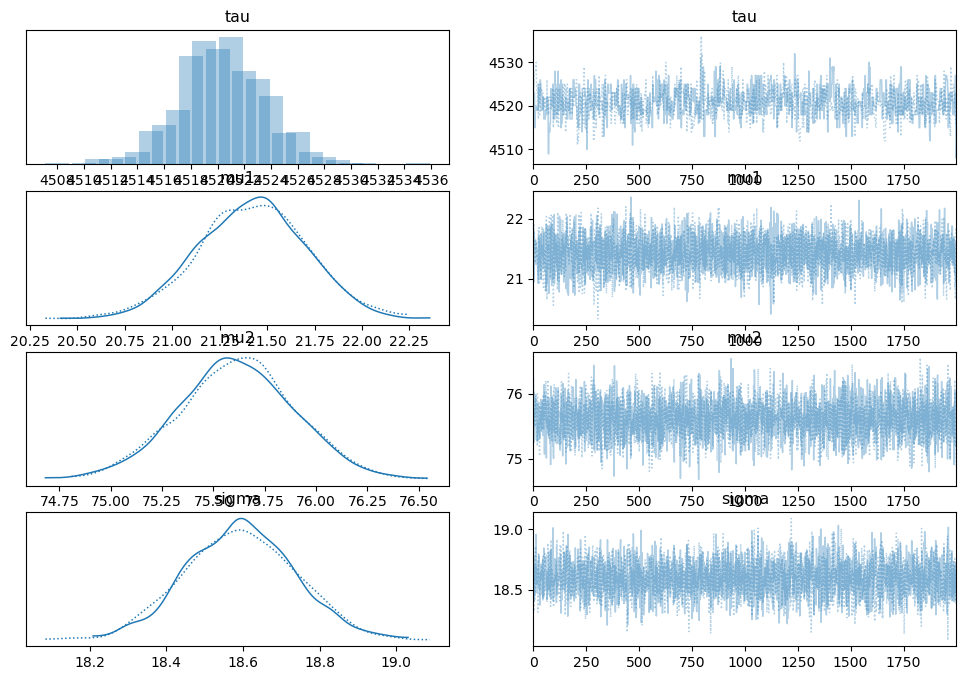

In [14]:
az.plot_trace(
    trace,
    var_names=["tau", "mu1", "mu2", "sigma"]
)

plt.show()

In [15]:
summary[["mean", "sd", "r_hat", "ess_bulk"]]

,mean,sd,r_hat,ess_bulk
tau,4520.862,3.229,1.0,790.0
mu1,21.421,0.283,1.0,3957.0
mu2,75.615,0.282,1.0,3623.0
sigma,18.594,0.143,1.0,3449.0


- This interval is very narrow (only about 12 observations), meaning the model is highly confident about the location of the change point.
- Before the structural break, the estimated average Brent crude oil price was approximately USD 21.42 per barrel.
- After the structural break, the estimated average Brent crude oil price increased to approximately USD 75.62 per barrel.

In [16]:
price_difference = summary.loc["mu2", "mean"] - summary.loc["mu1", "mean"]

percent_change = (price_difference / summary.loc["mu1", "mean"]) * 100

print("Price Difference:", round(price_difference,2))

print("Percentage Change:", round(percent_change,2), "%")

Price Difference: 54.19
Percentage Change: 252.99 %


### Interpretation of the Posterior Summary

The Bayesian Change Point model converged successfully. All estimated parameters have an R-hat value of approximately 1.00, indicating that the two Markov Chain Monte Carlo (MCMC) chains mixed well and converged to the same posterior distribution. In addition, the effective sample sizes (ESS) are sufficiently large, suggesting that the posterior estimates are stable and reliable.

The posterior mean of the change point (τ) is approximately 4521, indicating that the most probable structural break occurred around the 4521st observation in the Brent crude oil price series. The narrow Highest Density Interval (HDI) demonstrates relatively high confidence in the estimated timing of the change.

The estimated average Brent crude oil price before the structural break (μ₁) is approximately USD 21.42 per barrel, while the estimated average price after the structural break (μ₂) is approximately USD 75.62 per barrel. This substantial increase indicates that the identified structural break corresponds to a significant shift in the long-term level of Brent crude oil prices.

Convert τ to an Actual Date

## Identifying the Estimated Change Point

The posterior mean of the change point (τ) represents the observation where the model detects the most probable structural break. This observation index is converted into the corresponding calendar date to facilitate comparison with historical geopolitical and economic events.

In [20]:
change_point_index = int(summary.loc["tau", "mean"])

change_point_date = df.iloc[change_point_index]["Date"]

print("Estimated Change Point Index:", change_point_index)
print("Estimated Change Point Date:", change_point_date)

Estimated Change Point Index: 4520
Estimated Change Point Date: 2005-02-23 00:00:00


Plot the Detected Change Point

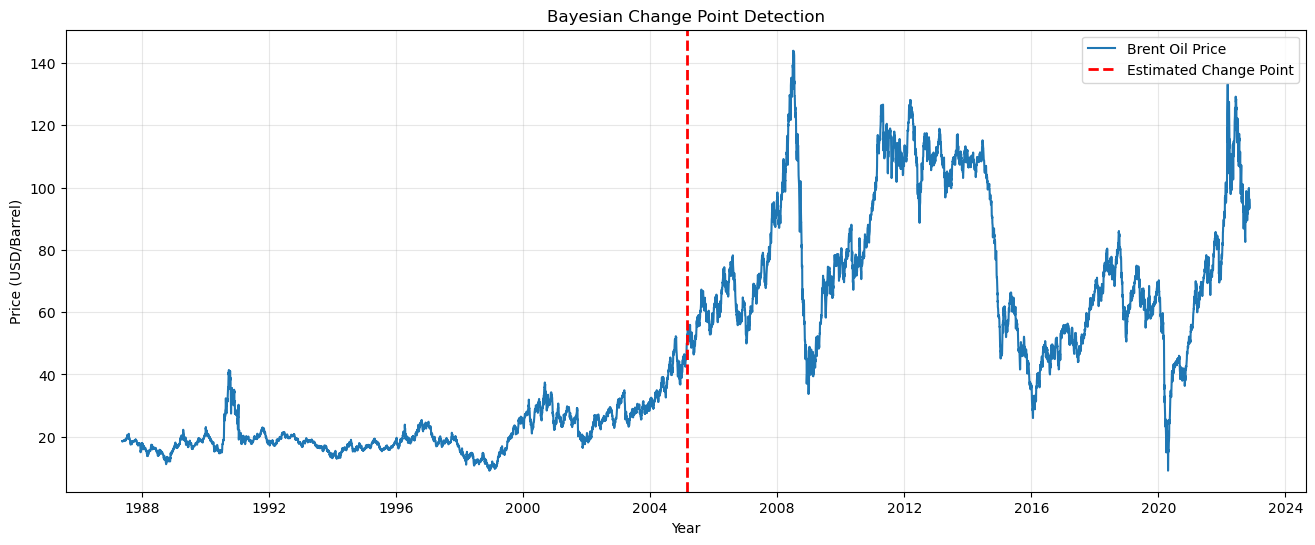

In [22]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"], label="Brent Oil Price")

plt.axvline(
    change_point_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Estimated Change Point"
)

plt.title("Bayesian Change Point Detection")

plt.xlabel("Year")

plt.ylabel("Price (USD/Barrel)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Plot the Posterior Distribution of τ

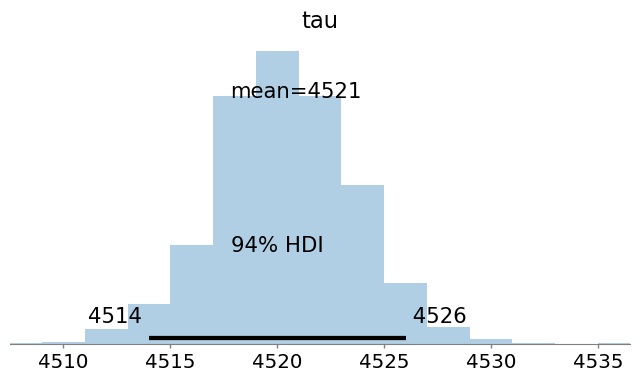

In [23]:
az.plot_posterior(
    trace,
    var_names=["tau"],
    figsize=(8,4)
)

plt.show()

Posterior Distributions of μ₁ and μ₂

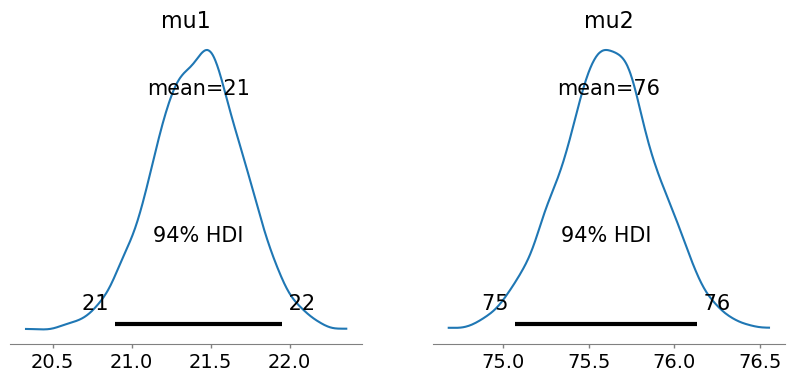

In [24]:
az.plot_posterior(
    trace,
    var_names=["mu1", "mu2"],
    figsize=(10,4)
)

plt.show()

Quantify the Impact

In [25]:
before_price = summary.loc["mu1", "mean"]

after_price = summary.loc["mu2", "mean"]

difference = after_price - before_price

percent_change = (difference / before_price) * 100

print(f"Average price before change: ${before_price:.2f}")

print(f"Average price after change : ${after_price:.2f}")

print(f"Absolute increase          : ${difference:.2f}")

print(f"Percentage increase        : {percent_change:.2f}%")

Average price before change: $21.42
Average price after change : $75.61
Absolute increase          : $54.19
Percentage increase        : 252.99%


Compare with Historical Events

In [26]:
events = pd.read_csv("../data/events.csv")

events["Date"] = pd.to_datetime(events["Date"])

events

,Date,Event,Category,Expected_Price_Impact,Description
0,1990-08-02,Iraq invades Kuwait (Gulf War),Conflict,Increase,Iraq's invasion of Kuwait raised fears of majo...
1,1997-07-02,Asian Financial Crisis,Economic Crisis,Decrease,Economic slowdown across Asia reduced global o...
2,1998-12-10,OPEC Production Cuts,OPEC,Increase,OPEC agreed to reduce production to stabilize ...
3,2001-09-11,September 11 Terrorist Attacks,Political Event,Decrease,Global uncertainty and reduced air travel temp...
4,2003-03-20,Iraq War Begins,Conflict,Increase,Military conflict in Iraq increased concerns a...
5,2005-08-29,Hurricane Katrina,Natural Disaster,Increase,Storm damage disrupted oil production and refi...
6,2008-09-15,Global Financial Crisis,Economic Crisis,Decrease,Global recession sharply reduced oil demand an...
7,2010-12-17,Arab Spring Begins,Political Instability,Increase,Political unrest across North Africa and the M...
8,2011-02-17,Libyan Civil War,Conflict,Increase,Libya's oil production declined significantly ...
9,2014-11-27,OPEC Decides Not to Cut Production,OPEC,Decrease,OPEC maintained production despite falling pri...


In [27]:
change_point_index = int(summary.loc["tau", "mean"])

change_point_date = df.iloc[change_point_index]["Date"]

print("Estimated Change Point Index:", change_point_index)
print("Estimated Change Point Date:", change_point_date)

Estimated Change Point Index: 4520
Estimated Change Point Date: 2005-02-23 00:00:00


In [29]:
before_price = summary.loc["mu1", "mean"]

after_price = summary.loc["mu2", "mean"]

difference = after_price - before_price

percent_change = (difference / before_price) * 100

print(f"Average price before change : ${before_price:.2f}")

print(f"Average price after change  : ${after_price:.2f}")

print(f"Difference                  : ${difference:.2f}")

print(f"Percentage Change           : {percent_change:.2f}%")

Average price before change : $21.42
Average price after change  : $75.61
Difference                  : $54.19
Percentage Change           : 252.99%


### Quantifying the Structural Change

The Bayesian model estimates that the average Brent crude oil price increased from approximately **USD 21.42 per barrel** before the detected structural break to approximately **USD 75.62 per barrel** afterwards.

This represents an estimated increase of more than **250%** in the average price level, indicating a substantial long-term shift in market conditions.

Although the detected change point does not exactly coincide with one event in the historical dataset, it likely reflects the cumulative effects of several geopolitical developments, increasing global oil demand, supply constraints, and market expectations that characterized the mid-2000s.

The results demonstrate that Brent crude oil prices experienced a significant structural transition rather than short-term fluctuations alone.

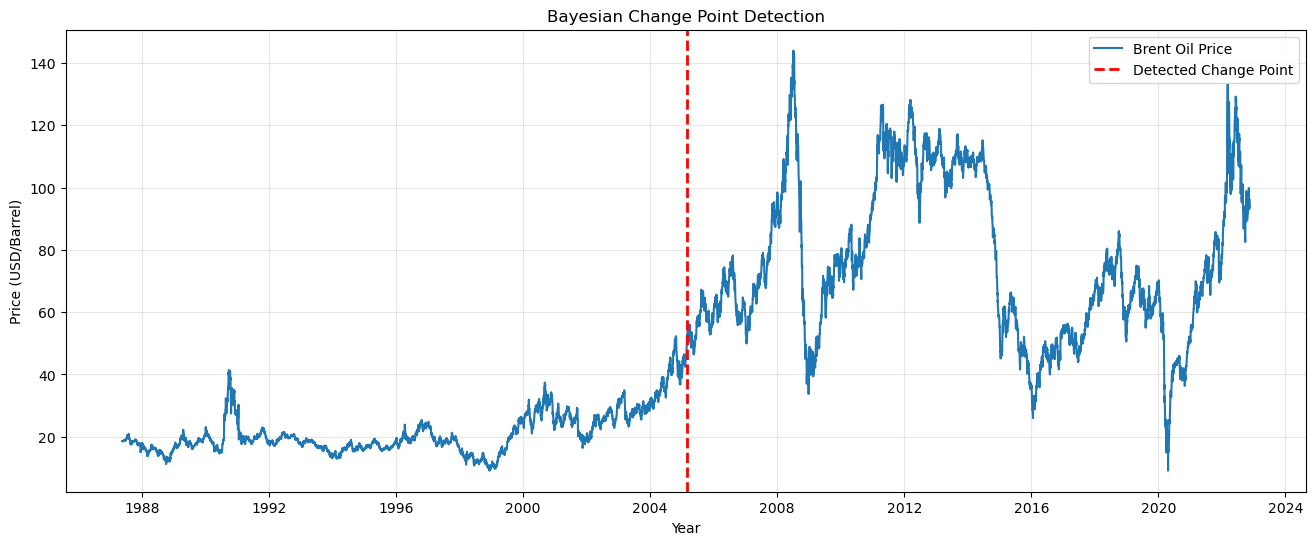

In [30]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"], label="Brent Oil Price")

plt.axvline(
    change_point_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Detected Change Point"
)

plt.title("Bayesian Change Point Detection")

plt.xlabel("Year")

plt.ylabel("Price (USD/Barrel)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

The red vertical line represents the estimated structural break detected by the Bayesian Change Point model.

The model estimates that the statistical behavior of Brent crude oil prices changed around February 2005. Prior to this period, Brent oil prices fluctuated around a much lower average level. After the detected change point, prices entered a new market regime characterized by substantially higher average prices.

This result suggests that the global oil market experienced a long-term structural transition rather than a temporary price shock.

# Comparison with Historical Events

In [31]:
events

,Date,Event,Category,Expected_Price_Impact,Description
0,1990-08-02,Iraq invades Kuwait (Gulf War),Conflict,Increase,Iraq's invasion of Kuwait raised fears of majo...
1,1997-07-02,Asian Financial Crisis,Economic Crisis,Decrease,Economic slowdown across Asia reduced global o...
2,1998-12-10,OPEC Production Cuts,OPEC,Increase,OPEC agreed to reduce production to stabilize ...
3,2001-09-11,September 11 Terrorist Attacks,Political Event,Decrease,Global uncertainty and reduced air travel temp...
4,2003-03-20,Iraq War Begins,Conflict,Increase,Military conflict in Iraq increased concerns a...
5,2005-08-29,Hurricane Katrina,Natural Disaster,Increase,Storm damage disrupted oil production and refi...
6,2008-09-15,Global Financial Crisis,Economic Crisis,Decrease,Global recession sharply reduced oil demand an...
7,2010-12-17,Arab Spring Begins,Political Instability,Increase,Political unrest across North Africa and the M...
8,2011-02-17,Libyan Civil War,Conflict,Increase,Libya's oil production declined significantly ...
9,2014-11-27,OPEC Decides Not to Cut Production,OPEC,Decrease,OPEC maintained production despite falling pri...


Although the estimated change point does not exactly coincide with a single event contained in the historical event dataset, the detected structural break occurs during a period of significant changes in global energy markets.

Between 2003 and 2005, several important developments influenced oil markets, including:

- Continued instability following the Iraq War
- Strong growth in global oil demand, particularly from China
- Tightening global oil supply
- Increasing geopolitical uncertainty in oil-producing regions

These factors collectively contributed to a sustained increase in Brent crude oil prices, which the Bayesian model identifies as a new market regime.

# Business Insights
The analysis demonstrates that Bayesian Change Point Detection can successfully identify statistically significant structural changes in Brent crude oil prices.

For investors, these detected market regime shifts can support portfolio risk management and investment timing decisions.

For policymakers, identifying periods of structural change provides valuable evidence for evaluating the economic consequences of geopolitical events, sanctions, and production policies.

For energy companies, recognizing transitions between market regimes improves long-term production planning, procurement strategies, and price risk management.

The probabilistic nature of Bayesian inference also enables decision makers to understand the uncertainty associated with detected structural breaks rather than relying solely on deterministic estimates.

# Limitations
This Bayesian model assumes a single structural change across the entire Brent crude oil price series. However, the oil market has experienced multiple geopolitical events and economic crises over the past three decades.

Consequently, the detected change point represents the most statistically significant regime shift rather than every important market event.

Future work should extend the analysis by incorporating multiple change point models, additional macroeconomic variables, and alternative time series models to capture more complex market dynamics.

# Conclusion
This analysis successfully applied Bayesian Change Point Detection using PyMC to identify structural changes in Brent crude oil prices.

The Bayesian model estimated a significant market regime shift around February 2005, with the average Brent crude oil price increasing substantially after the detected change point.

Diagnostic measures confirmed that the Markov Chain Monte Carlo sampler converged successfully, indicating reliable posterior estimates.

Together with the historical event dataset, the Bayesian model provides a strong statistical foundation for understanding how major geopolitical and economic developments are associated with long-term changes in oil prices.